In [2]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [3]:
# df = pd.read_csv("D:\projek\Analisis\Indian Stock Market Dataset PE, Market Cap\dataset\indian_stock_market.csv")
df = pd.read_csv("dataset/indian_stock_market.csv", sep=";")

print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.describe())

(5258, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5258 entries, 0 to 5257
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Company                          5258 non-null   object 
 1   Current_Price_INR                5238 non-null   float64
 2   PE_Ratio                         4231 non-null   float64
 3   Market_Cap_Crore                 5258 non-null   float64
 4   Quarterly_Profit_Growth_Percent  5096 non-null   float64
 5   Quarterly_Sales_Growth_Percent   4816 non-null   float64
 6   ROCE_Percent                     5118 non-null   float64
 7   Collection_Date                  5258 non-null   object 
dtypes: float64(6), object(2)
memory usage: 328.8+ KB
None
Company                               0
Current_Price_INR                    20
PE_Ratio                           1027
Market_Cap_Crore                      0
Quarterly_Profit_Growth_Percent     162
Quart

Ceaning Data

In [4]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [5]:
print("Duplicate companies:", df["Company"].duplicated().sum())

Duplicate companies: 0


check Colection date

In [6]:
df["Collection_Date"] = pd.to_datetime(df["Collection_Date"])

print(df["Collection_Date"].min())
print(df["Collection_Date"].max())
print(df["Collection_Date"].value_counts().sort_index())

2026-06-26 00:00:00
2026-06-26 00:00:00
Collection_Date
2026-06-26    5258
Name: count, dtype: int64


C:\Users\latifmaruf\AppData\Local\Temp\ipykernel_14028\3754388672.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Collection_Date"] = pd.to_datetime(df["Collection_Date"])


negative value

In [7]:
print("Negative Price:")
print((df["Current_Price_INR"] < 0).sum())

print("Negative PE:")
print((df["PE_Ratio"] < 0).sum())

print("Negative Market Cap:")
print((df["Market_Cap_Crore"] < 0).sum())

print("Negative Profit Growth:")
print((df["Quarterly_Profit_Growth_Percent"] < 0).sum())

print("Negative Sales Growth:")
print((df["Quarterly_Sales_Growth_Percent"] < 0).sum())

print("Negative ROCE:")
print((df["ROCE_Percent"] < 0).sum())

Negative Price:
0
Negative PE:
0
Negative Market Cap:
0
Negative Profit Growth:
2133
Negative Sales Growth:
1498
Negative ROCE:
705


In [8]:
pe_filtered = df[df["PE_Ratio"] <= df["PE_Ratio"].quantile(0.95)]

In [9]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate companies:", df["Company"].duplicated().sum())

df["Collection_Date"] = pd.to_datetime(df["Collection_Date"])

print("\nDate range:")
print(df["Collection_Date"].min())
print(df["Collection_Date"].max())

print("\nDate distribution:")
print(df["Collection_Date"].value_counts().sort_index())

Duplicate rows: 0
Duplicate companies: 0

Date range:
2026-06-26 00:00:00
2026-06-26 00:00:00

Date distribution:
Collection_Date
2026-06-26    5258
Name: count, dtype: int64


Profiling numbers

In [10]:
numeric_cols = [
    "Current_Price_INR",
    "PE_Ratio",
    "Market_Cap_Crore",
    "Quarterly_Profit_Growth_Percent",
    "Quarterly_Sales_Growth_Percent",
    "ROCE_Percent"
]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"\n{col}")
    print(f"Q1       : {Q1:.2f}")
    print(f"Q3       : {Q3:.2f}")
    print(f"IQR      : {IQR:.2f}")
    print(f"Lower    : {lower:.2f}")
    print(f"Upper    : {upper:.2f}")
    print(f"Outliers : {outliers}")


Current_Price_INR
Q1       : 26.29
Q3       : 314.83
IQR      : 288.53
Lower    : -406.51
Upper    : 747.63
Outliers : 671

PE_Ratio
Q1       : 13.45
Q3       : 48.36
IQR      : 34.91
Lower    : -38.92
Upper    : 100.72
Outliers : 483

Market_Cap_Crore
Q1       : 43.53
Q3       : 1612.71
IQR      : 1569.18
Lower    : -2310.24
Upper    : 3966.49
Outliers : 917

Quarterly_Profit_Growth_Percent
Q1       : -48.06
Q3       : 90.52
IQR      : 138.57
Lower    : -255.92
Upper    : 298.37
Outliers : 773

Quarterly_Sales_Growth_Percent
Q1       : -6.30
Q3       : 36.17
IQR      : 42.48
Lower    : -70.02
Upper    : 99.89
Outliers : 755

ROCE_Percent
Q1       : 3.27
Q3       : 17.81
IQR      : 14.54
Lower    : -18.53
Upper    : 39.62
Outliers : 347


In [11]:
pe_visual = df[df["PE_Ratio"] <= df["PE_Ratio"].quantile(0.95)]

Exploration Data


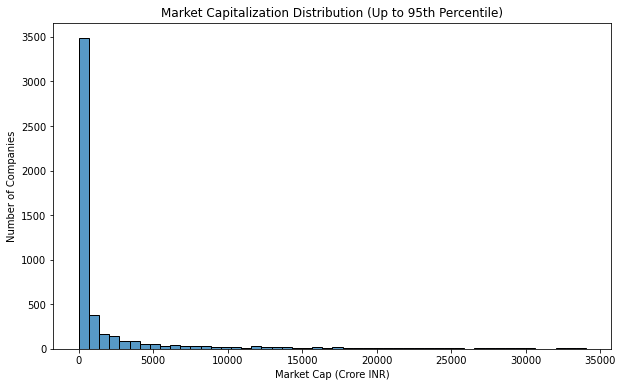

In [12]:
market_cap_visual = df[
    df["Market_Cap_Crore"] <= df["Market_Cap_Crore"].quantile(0.95)
]

plt.figure(figsize=(10, 6))

sns.histplot(
    market_cap_visual["Market_Cap_Crore"],
    bins=50
)

plt.title("Market Capitalization Distribution (Up to 95th Percentile)")
plt.xlabel("Market Cap (Crore INR)")
plt.ylabel("Number of Companies")

plt.show()

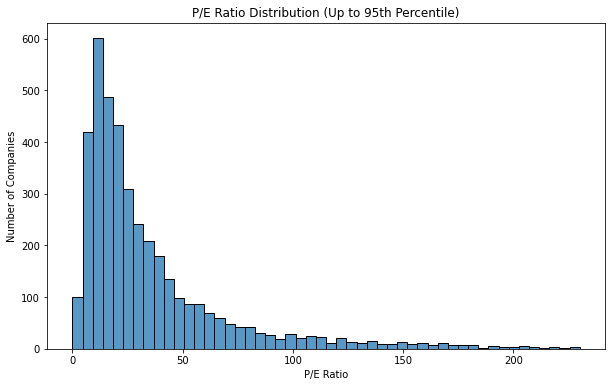

In [13]:
pe_visual = df[
    df["PE_Ratio"].notna() &
    (df["PE_Ratio"] <= df["PE_Ratio"].quantile(0.95))
]

plt.figure(figsize=(10, 6))

sns.histplot(
    pe_visual["PE_Ratio"],
    bins=50
)

plt.title("P/E Ratio Distribution (Up to 95th Percentile)")
plt.xlabel("P/E Ratio")
plt.ylabel("Number of Companies")

plt.show()

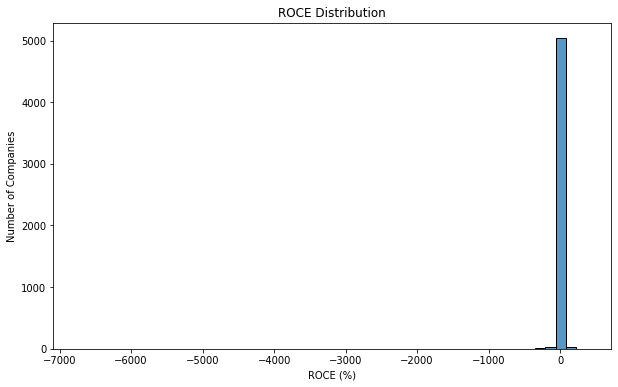

In [14]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["ROCE_Percent"].dropna(),
    bins=50
)

plt.title("ROCE Distribution")
plt.xlabel("ROCE (%)")
plt.ylabel("Number of Companies")

plt.show()

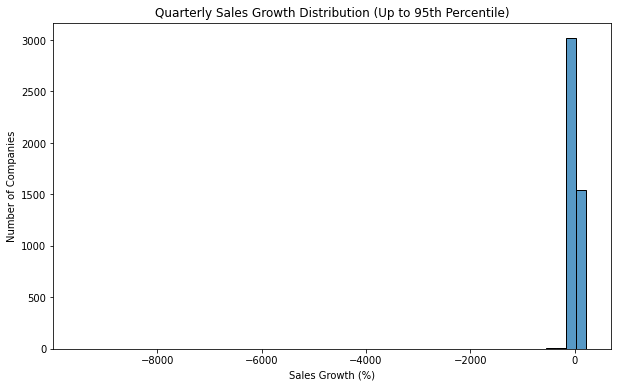

In [15]:
sales_visual = df[
    df["Quarterly_Sales_Growth_Percent"].notna() &
    (df["Quarterly_Sales_Growth_Percent"] <= 
     df["Quarterly_Sales_Growth_Percent"].quantile(0.95))
]

plt.figure(figsize=(10, 6))

sns.histplot(
    sales_visual["Quarterly_Sales_Growth_Percent"],
    bins=50
)

plt.title("Quarterly Sales Growth Distribution (Up to 95th Percentile)")
plt.xlabel("Sales Growth (%)")
plt.ylabel("Number of Companies")

plt.show()

In [16]:
print("P/E asli:")
print(df["PE_Ratio"].describe())

print("\nP/E 95%:")
print(df["PE_Ratio"].quantile(0.95))

print("\nMarket Cap asli:")
print(df["Market_Cap_Crore"].describe())

print("\nMarket Cap 95%:")
print(df["Market_Cap_Crore"].quantile(0.95))

P/E asli:
count     4231.000000
mean       104.113682
std       1312.242598
min          0.010000
25%         13.445000
50%         24.100000
75%         48.355000
max      75839.000000
Name: PE_Ratio, dtype: float64

P/E 95%:
230.39

Market Cap asli:
count    5.258000e+03
mean     9.137135e+03
std      5.311407e+04
min      5.010000e+00
25%      4.353000e+01
50%      1.999050e+02
75%      1.612713e+03
max      1.783723e+06
Name: Market_Cap_Crore, dtype: float64

Market Cap 95%:
34080.769499999944


Apakah perusahaan dengan Market Cap besar cenderung memiliki P/E Ratio yang lebih tinggi? <br><br>
Bivariate Analysis


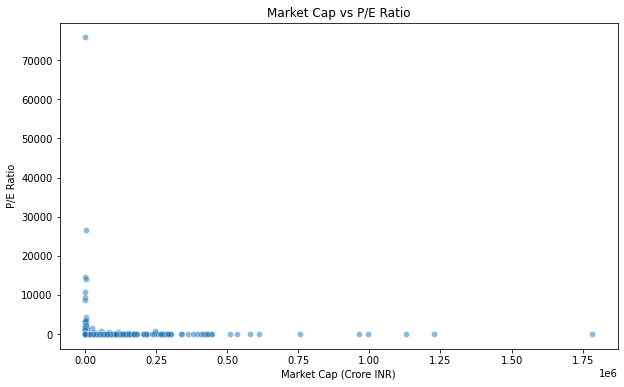

In [17]:
pe_marketcap = df[
    ["Market_Cap_Crore", "PE_Ratio"]
].dropna()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pe_marketcap,
    x="Market_Cap_Crore",
    y="PE_Ratio",
    alpha=0.5
)

plt.title("Market Cap vs P/E Ratio")
plt.xlabel("Market Cap (Crore INR)")
plt.ylabel("P/E Ratio")

plt.show()

Log Scale


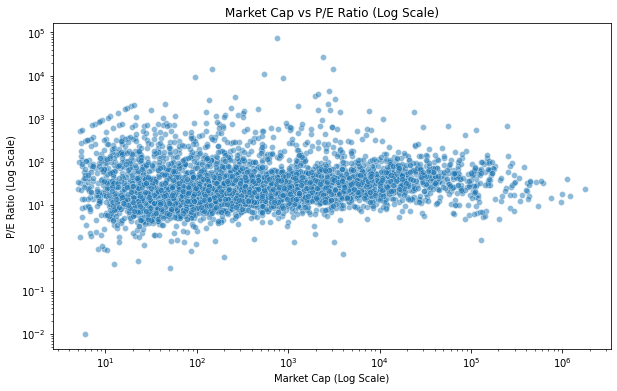

In [18]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pe_marketcap,
    x="Market_Cap_Crore",
    y="PE_Ratio",
    alpha=0.5
)

plt.xscale("log")
plt.yscale("log")

plt.title("Market Cap vs P/E Ratio (Log Scale)")
plt.xlabel("Market Cap (Log Scale)")
plt.ylabel("P/E Ratio (Log Scale)")

plt.show()

Correlation

In [19]:
correlation = pe_marketcap["Market_Cap_Crore"].corr(
    pe_marketcap["PE_Ratio"]
)

print("Correlation:", correlation)

spearman = pe_marketcap["Market_Cap_Crore"].corr(
    pe_marketcap["PE_Ratio"],
    method="spearman"
)

print("Pearson:", correlation)
print("Spearman:", spearman)

Correlation: -0.0071763053509592565
Pearson: -0.0071763053509592565
Spearman: 0.1887377042154274


Market capitalization menunjukkan hubungan linear yang hampir tidak ada dengan P/E Ratio (Pearson = -0,007). Namun, korelasi Spearman sebesar 0,189 menunjukkan adanya hubungan positif yang lemah berdasarkan peringkat perusahaan. Hal ini menunjukkan bahwa ukuran perusahaan bukan faktor utama yang menjelaskan variasi P/E Ratio dalam dataset ini.

scatter plot yang lebih representatif dengan membatasi extreme values berdasarkan 95th percentile:

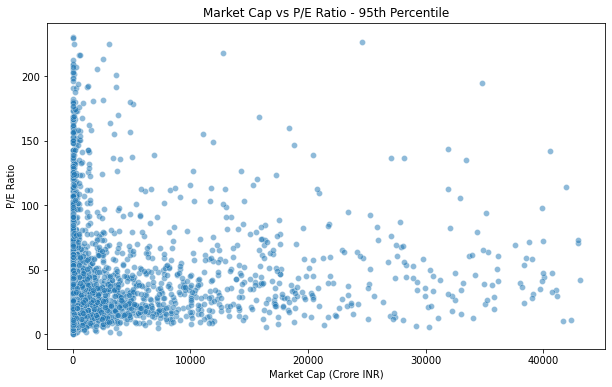

In [20]:
pe_marketcap_visual = pe_marketcap[
    (pe_marketcap["Market_Cap_Crore"] <=
     pe_marketcap["Market_Cap_Crore"].quantile(0.95)) &
    (pe_marketcap["PE_Ratio"] <=
     pe_marketcap["PE_Ratio"].quantile(0.95))
]

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pe_marketcap_visual,
    x="Market_Cap_Crore",
    y="PE_Ratio",
    alpha=0.5
)

plt.title("Market Cap vs P/E Ratio - 95th Percentile")
plt.xlabel("Market Cap (Crore INR)")
plt.ylabel("P/E Ratio")

plt.show()

Sales Growth vs Profit Growth.


In [21]:
growth_df = df[
    [
        "Company",
        "Quarterly_Sales_Growth_Percent",
        "Quarterly_Profit_Growth_Percent"
    ]
].dropna()

print(growth_df.shape)
print(growth_df.describe())

(4795, 3)
       Quarterly_Sales_Growth_Percent  Quarterly_Profit_Growth_Percent
count                    4.795000e+03                      4795.000000
mean                     1.479653e+03                        45.974388
std                      8.860722e+04                      2882.723274
min                     -9.500000e+03                    -59400.000000
25%                     -6.275000e+00                       -46.305000
50%                      1.238000e+01                        15.380000
75%                      3.591000e+01                        88.525000
max                      6.125900e+06                    143333.330000


In [22]:
pearson = growth_df[
    "Quarterly_Sales_Growth_Percent"
].corr(
    growth_df["Quarterly_Profit_Growth_Percent"]
)

spearman = growth_df[
    "Quarterly_Sales_Growth_Percent"
].corr(
    growth_df["Quarterly_Profit_Growth_Percent"],
    method="spearman"
)

print("Pearson:", pearson)
print("Spearman:", spearman)

Pearson: 0.002273359579662591
Spearman: 0.3569453767818076


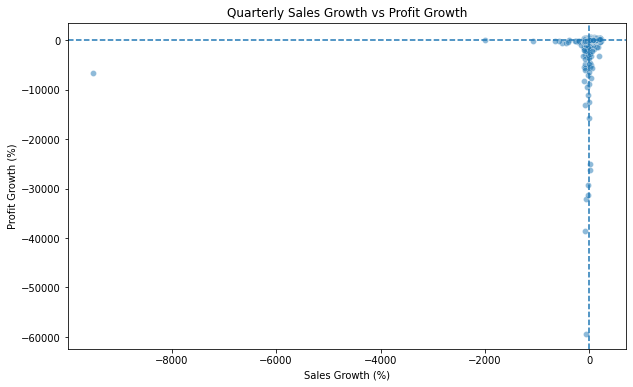

In [23]:
sales_limit = growth_df[
    "Quarterly_Sales_Growth_Percent"
].quantile(0.95)

profit_limit = growth_df[
    "Quarterly_Profit_Growth_Percent"
].quantile(0.95)

growth_visual = growth_df[
    (growth_df["Quarterly_Sales_Growth_Percent"] <= sales_limit) &
    (growth_df["Quarterly_Profit_Growth_Percent"] <= profit_limit)
]

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=growth_visual,
    x="Quarterly_Sales_Growth_Percent",
    y="Quarterly_Profit_Growth_Percent",
    alpha=0.5
)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.title("Quarterly Sales Growth vs Profit Growth")
plt.xlabel("Sales Growth (%)")
plt.ylabel("Profit Growth (%)")

plt.show()


In [24]:
print(growth_df[
    [
        "Quarterly_Sales_Growth_Percent",
        "Quarterly_Profit_Growth_Percent"
    ]
].describe())

       Quarterly_Sales_Growth_Percent  Quarterly_Profit_Growth_Percent
count                    4.795000e+03                      4795.000000
mean                     1.479653e+03                        45.974388
std                      8.860722e+04                      2882.723274
min                     -9.500000e+03                    -59400.000000
25%                     -6.275000e+00                       -46.305000
50%                      1.238000e+01                        15.380000
75%                      3.591000e+01                        88.525000
max                      6.125900e+06                    143333.330000


In [25]:
near_zero = growth_df[
    (growth_df["Quarterly_Sales_Growth_Percent"].between(-5, 5)) &
    (growth_df["Quarterly_Profit_Growth_Percent"].between(-5, 5))
]

print("Data di sekitar 0%:", len(near_zero))
print("Persentase:", len(near_zero) / len(growth_df) * 100, "%")

Data di sekitar 0%: 40
Persentase: 0.8342022940563086 %


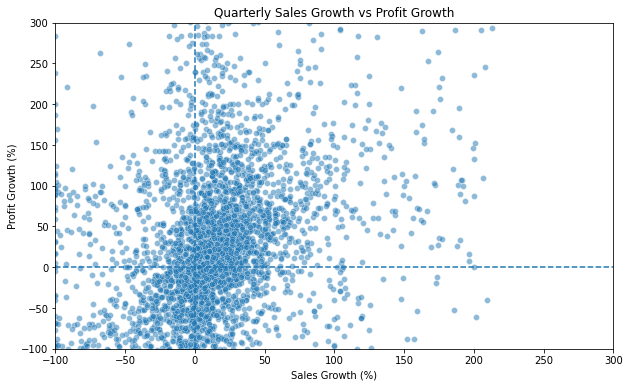

In [26]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=growth_visual,
    x="Quarterly_Sales_Growth_Percent",
    y="Quarterly_Profit_Growth_Percent",
    alpha=0.5
)

plt.xlim(-100, 300)
plt.ylim(-100, 300)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.title("Quarterly Sales Growth vs Profit Growth")
plt.xlabel("Sales Growth (%)")
plt.ylabel("Profit Growth (%)")

plt.show()

kenapa banya penumpukan di 0?? karna sangat sedikit perusahaan yang benar benar berada di sekitar -5% sampai 5% hal oleh karena itu outlier values membuat skala grafik yang lebar, coba kita benerin grafiknya dengan menggunakan percentile 95%, kenapa 95%? karna ingin melihat pola mayoritas 95% perusahaan sedangkan 5% extreme values di keluarkan dari visualisasi.


In [27]:
sales_limit = growth_df[
    "Quarterly_Sales_Growth_Percent"
].quantile(0.95)

profit_limit = growth_df[
    "Quarterly_Profit_Growth_Percent"
].quantile(0.95)

print("Sales 95%:", sales_limit)
print("Profit 95%:", profit_limit)

Sales 95%: 212.8420000000001
Profit 95%: 535.5070000000004


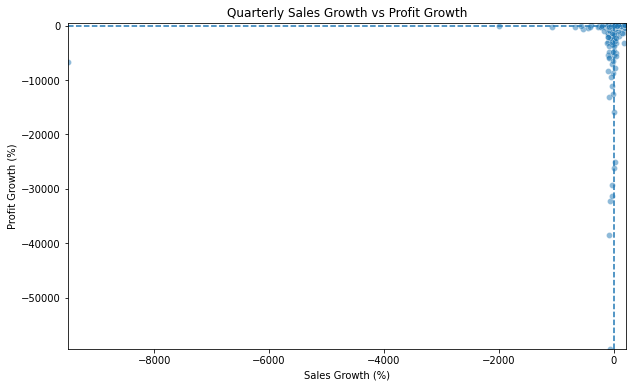

In [28]:
growth_visual = growth_df[
    (growth_df["Quarterly_Sales_Growth_Percent"] <= sales_limit) &
    (growth_df["Quarterly_Profit_Growth_Percent"] <= profit_limit)
]

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=growth_visual,
    x="Quarterly_Sales_Growth_Percent",
    y="Quarterly_Profit_Growth_Percent",
    alpha=0.5
)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlim(
    growth_visual["Quarterly_Sales_Growth_Percent"].min(),
    sales_limit
)

plt.ylim(
    growth_visual["Quarterly_Profit_Growth_Percent"].min(),
    profit_limit
)

plt.title("Quarterly Sales Growth vs Profit Growth")
plt.xlabel("Sales Growth (%)")
plt.ylabel("Profit Growth (%)")

plt.show()

In [29]:
df

,Company,Current_Price_INR,PE_Ratio,Market_Cap_Crore,Quarterly_Profit_Growth_Percent,Quarterly_Sales_Growth_Percent,ROCE_Percent,Collection_Date
0,20 Microns,200.08,10.52,706.01,14.99,14.80,17.43,2026-06-26
1,21st Cent. Mgmt.,33.20,NaN,34.86,-19.06,-27.89,-57.00,2026-06-26
2,360 ONE,1085.40,36.30,44141.59,15.68,35.91,12.13,2026-06-26
3,3B Blackbio,1159.70,16.99,995.33,13.81,57.47,25.48,2026-06-26
4,3B Films,16.58,22.32,41.07,36.76,-11.85,4.83,2026-06-26
...,...,...,...,...,...,...,...,...
5253,ZR2 Bioenergy,106.10,168.90,168.90,81.82,NaN,0.70,2026-06-26
5254,Zuari Agro Chem.,230.98,3.27,971.46,-212.74,-80.32,16.38,2026-06-26
5255,Zuari Industries,260.65,6.69,776.25,-56.79,4.15,5.45,2026-06-26
5256,Zydus Lifesci.,1101.40,20.43,110826.61,21.92,16.22,21.15,2026-06-26


In [30]:
growth_df = df[
    [
        "Company",
        "Quarterly_Sales_Growth_Percent",
        "Quarterly_Profit_Growth_Percent"
    ]
].dropna()

print(growth_df.shape)
print(growth_df.head())

(4795, 3)
            Company  Quarterly_Sales_Growth_Percent  \
0        20 Microns                           14.80   
1  21st Cent. Mgmt.                          -27.89   
2           360 ONE                           35.91   
3       3B Blackbio                           57.47   
4          3B Films                          -11.85   

   Quarterly_Profit_Growth_Percent  
0                            14.99  
1                           -19.06  
2                            15.68  
3                            13.81  
4                            36.76  


analisis 4 kuadran

In [31]:
# Buat kategori berdasarkan Sales Growth dan Profit Growth
def classify_growth(row):
    sales = row["Quarterly_Sales_Growth_Percent"]
    profit = row["Quarterly_Profit_Growth_Percent"]

    if sales >= 0 and profit >= 0:
        return "Sales ↑ / Profit ↑"
    elif sales >= 0 and profit < 0:
        return "Sales ↑ / Profit ↓"
    elif sales < 0 and profit >= 0:
        return "Sales ↓ / Profit ↑"
    else:
        return "Sales ↓ / Profit ↓"


growth_df["Growth_Category"] = growth_df.apply(classify_growth, axis=1)

print(growth_df["Growth_Category"].value_counts())

category_percentage = (
    growth_df["Growth_Category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(category_percentage)

Growth_Category
Sales ↑ / Profit ↑    2254
Sales ↑ / Profit ↓    1049
Sales ↓ / Profit ↓     950
Sales ↓ / Profit ↑     542
Name: count, dtype: int64
Growth_Category
Sales ↑ / Profit ↑    47.01
Sales ↑ / Profit ↓    21.88
Sales ↓ / Profit ↓    19.81
Sales ↓ / Profit ↑    11.30
Name: proportion, dtype: float64


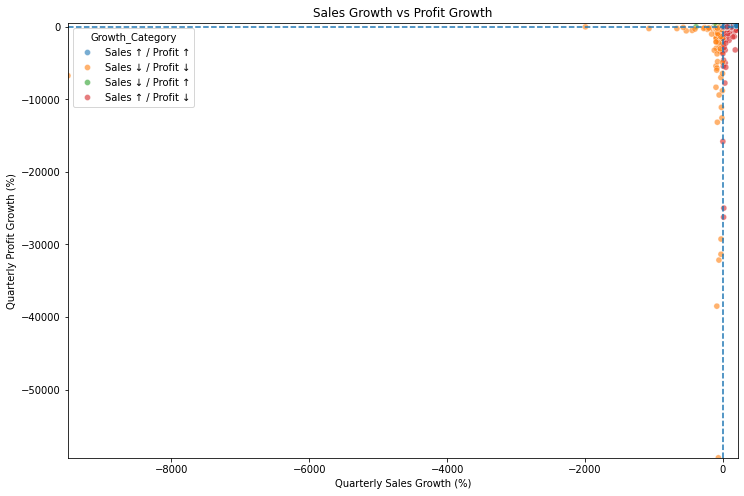

In [32]:
sales_limit = growth_df[
    "Quarterly_Sales_Growth_Percent"
].quantile(0.95)

profit_limit = growth_df[
    "Quarterly_Profit_Growth_Percent"
].quantile(0.95)

growth_visual = growth_df[
    (growth_df["Quarterly_Sales_Growth_Percent"] <= sales_limit) &
    (growth_df["Quarterly_Profit_Growth_Percent"] <= profit_limit)
]

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=growth_visual,
    x="Quarterly_Sales_Growth_Percent",
    y="Quarterly_Profit_Growth_Percent",
    hue="Growth_Category",
    alpha=0.6
)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlim(
    growth_visual["Quarterly_Sales_Growth_Percent"].min(),
    sales_limit
)

plt.ylim(
    growth_visual["Quarterly_Profit_Growth_Percent"].min(),
    profit_limit
)

plt.title("Sales Growth vs Profit Growth")
plt.xlabel("Quarterly Sales Growth (%)")
plt.ylabel("Quarterly Profit Growth (%)")

plt.show()

1. hampir setengah perusahaan berada di kondisi yang positif sebanyak 47,01% (2.254) perusahaan mengalami kenaikan sales & Profit sekaligus 
2. terdapat 21,88% (1.049) perusahaan mednapat kenaikan sales namun profitnya turun
3. 19,81% (950) perusahaan yang mengalami penuruna di kedua sektor tersebut (Sales & profit)
4. namun 11,30% (542) mengalami kenaikan profit walau salesnya turun

berdasarkan data tersebut menunjukan bahwa pertumbuhan pendapatan tidak selalu diikuti oleh pertumbuhan profitabilitas.

ROCE vs P/E Ratio


ROCE yang tinggi apakah juga mempunya P/E yang lebih tinggi?

In [33]:
roce_pe_df = df[
    [
        "Company",
        "ROCE_Percent",
        "PE_Ratio"
    ]
].dropna()

print(roce_pe_df.shape)
print(roce_pe_df.describe())

(4174, 3)
       ROCE_Percent      PE_Ratio
count   4174.000000   4174.000000
mean      15.424605    104.482817
std       16.285087   1321.050776
min     -192.830000      0.010000
25%        6.922500     13.490000
50%       12.170000     24.120000
75%       19.707500     48.485000
max      361.900000  75839.000000


In [34]:
pearson = roce_pe_df["ROCE_Percent"].corr(
    roce_pe_df["PE_Ratio"]
)

spearman = roce_pe_df["ROCE_Percent"].corr(
    roce_pe_df["PE_Ratio"],
    method="spearman"
)

print("Pearson:", pearson)
print("Spearman:", spearman)


Pearson: -0.2090234011190742
Spearman: -0.34056289886346364


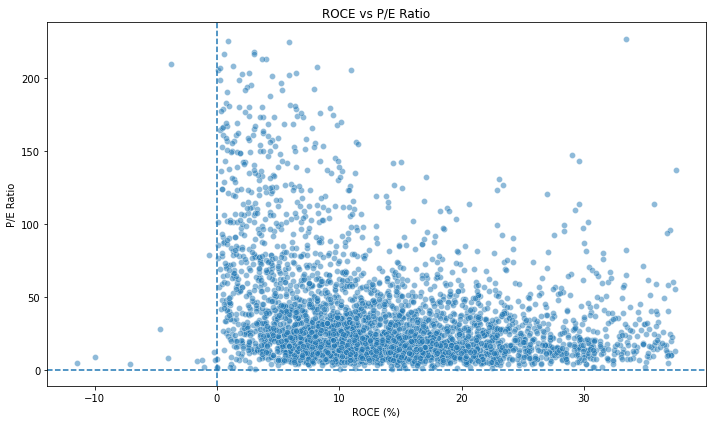

In [35]:
roce_limit = roce_pe_df["ROCE_Percent"].quantile(0.95)
pe_limit = roce_pe_df["PE_Ratio"].quantile(0.95)

roce_pe_visual = roce_pe_df[
    (roce_pe_df["ROCE_Percent"] <= roce_limit) &
    (roce_pe_df["PE_Ratio"] <= pe_limit)
]

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=roce_pe_visual,
    x="ROCE_Percent",
    y="PE_Ratio",
    alpha=0.5
)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.title("ROCE vs P/E Ratio")
plt.xlabel("ROCE (%)")
plt.ylabel("P/E Ratio")

plt.tight_layout()
plt.show()

ROCE menunjukkan hubungan negatif dengan P/E Ratio, dengan korelasi Pearson sebesar -0,209 dan Spearman sebesar -0,341. Hasil ini menunjukkan adanya kecenderungan bahwa perusahaan dengan ROCE yang lebih tinggi memiliki P/E Ratio yang lebih rendah. Namun, kekuatan hubungan tersebut relatif lemah hingga sedang, sehingga ROCE bukan satu-satunya faktor yang menjelaskan variasi P/E Ratio.

top 10 market cap


                Company  Market_Cap_Crore
1   Reliance Industries        1783723.44
2             HDFC Bank        1226366.46
3         Bharti Airtel        1127683.22
4            ICICI Bank         995339.18
5                   SBI         964968.76
6                   TCS         757880.79
7         Bajaj Finance         610392.56
8       Larsen & Toubro         580062.45
9        Life Insurance         535537.56
10       Hind. Unilever         510848.13


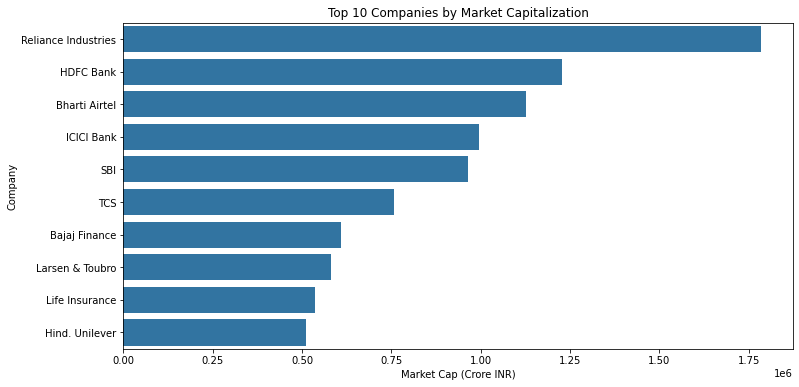

In [36]:
top_market_cap = df[
    ["Company", "Market_Cap_Crore"]
].dropna().sort_values(
    "Market_Cap_Crore",
    ascending=False
).head(10)

top_market_cap = top_market_cap.reset_index(drop=True)
top_market_cap.index = top_market_cap.index + 1

print(top_market_cap)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_market_cap,
    x="Market_Cap_Crore",
    y="Company"
)

plt.title("Top 10 Companies by Market Capitalization")
plt.xlabel("Market Cap (Crore INR)")
plt.ylabel("Company")

plt.show()



Grafik menunjukkan 10 perusahaan dengan Market Capitalization terbesar dalam dataset. Reliance Industries menempati posisi pertama dengan Market Cap sebesar ₹1.783.723,44 crore, diikuti HDFC Bank dan Bharti Airtel. Hasil ini menunjukkan dominasi perusahaan-perusahaan berkapitalisasi besar dalam pasar saham India.

Top 10 Sales Growth

Sales Growth 95th percentile: 216.185

Top 10 Sales Growth:
               Company  Quarterly_Sales_Growth_Percent
5047     Vilin Bio Med                          215.89
2667  Macobs Technolo.                          214.59
5168     White Organic                          213.33
1424            Falcon                          213.22
1774    Gujarat Kidney                          212.68
4972     Varvee Global                          211.73
593    Bandaram Pharma                          209.31
5097     Viviana Power                          208.24
2396  Kernex Microsys.                          206.46
2966  Multi Comm. Exc.                          205.13


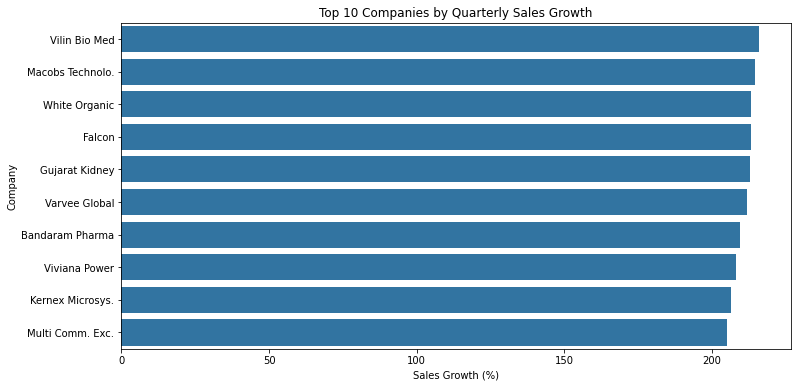

In [37]:
# Menentukan batas 95th percentile
sales_95 = df["Quarterly_Sales_Growth_Percent"].quantile(0.95)

print("Sales Growth 95th percentile:", sales_95)

# Mengambil Top 10 Sales Growth yang lebih representatif
top_sales_growth_clean = df[
    df["Quarterly_Sales_Growth_Percent"].notna() &
    (df["Quarterly_Sales_Growth_Percent"] <= sales_95)
].sort_values(
    by="Quarterly_Sales_Growth_Percent",
    ascending=False
).head(10)

print("\nTop 10 Sales Growth:")
print(
    top_sales_growth_clean[
        ["Company", "Quarterly_Sales_Growth_Percent"]
    ]
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_sales_growth_clean,
    x="Quarterly_Sales_Growth_Percent",
    y="Company"
)

plt.title("Top 10 Companies by Quarterly Sales Growth")
plt.xlabel("Sales Growth (%)")
plt.ylabel("Company")

plt.show()

In [38]:
top_sales_analysis = df[
    [
        "Company",
        "Quarterly_Sales_Growth_Percent",
        "Quarterly_Profit_Growth_Percent",
        "ROCE_Percent",
        "PE_Ratio",
        "Market_Cap_Crore"
    ]
].dropna(subset=["Quarterly_Sales_Growth_Percent"])

top_sales_analysis = top_sales_analysis[
    top_sales_analysis["Quarterly_Sales_Growth_Percent"] <=
    df["Quarterly_Sales_Growth_Percent"].quantile(0.95)
].sort_values(
    "Quarterly_Sales_Growth_Percent",
    ascending=False
).head(10)

print(top_sales_analysis.to_string(index=False))

         Company  Quarterly_Sales_Growth_Percent  Quarterly_Profit_Growth_Percent  ROCE_Percent  PE_Ratio  Market_Cap_Crore
   Vilin Bio Med                          215.89                          1680.00         10.77     32.83             63.36
Macobs Technolo.                          214.59                            92.21          0.11     76.84            222.84
   White Organic                          213.33                          -210.53          2.50     13.43             13.16
          Falcon                          213.22                           654.29          9.55      9.99             30.27
  Gujarat Kidney                          212.68                           293.75         14.48     65.73           1018.89
   Varvee Global                          211.73                          -222.32         18.90     27.33            340.24
 Bandaram Pharma                          209.31                           -40.00          4.42    121.13             54.51
   Vivia

Grafik menunjukkan 10 perusahaan dengan Quarterly Sales Growth tertinggi setelah extreme values dibatasi menggunakan 95th percentile sebesar 216,185%. Vilin Bio Med memiliki Sales Growth tertinggi sebesar 215,89%, diikuti Macobs Technolo. dan White Organic. Hasil ini menunjukkan adanya perusahaan dengan pertumbuhan penjualan lebih dari dua kali lipat dibandingkan periode sebelumnya.

Top 10 Profit Growth

Profit Growth 95th percentile: 600.0

Top 10 Profit Growth:
               Company  Quarterly_Profit_Growth_Percent
5225  Yuranus Infrast.                           600.00
358    Archidply Decor                           600.00
4829         TVS Elec.                           600.00
2590       Lexoraa Ind                           600.00
543     B N Rathi Sec.                           592.11
550        B.L.Kashyap                           591.26
2684      Magnus Steel                           590.91
2213     Jaykay Enter.                           586.84
143   Aelea Commoditi.                           583.14
1117     Deep Polymers                           576.92


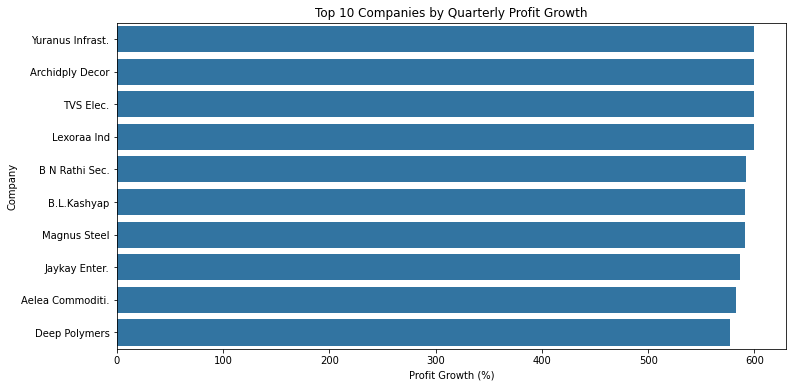

In [39]:
profit_95 = df["Quarterly_Profit_Growth_Percent"].quantile(0.95)

print("Profit Growth 95th percentile:", profit_95)

top_profit_growth_clean = df[
    df["Quarterly_Profit_Growth_Percent"].notna() &
    (df["Quarterly_Profit_Growth_Percent"] <= profit_95)
].sort_values(
    by="Quarterly_Profit_Growth_Percent",
    ascending=False
).head(10)

print("\nTop 10 Profit Growth:")
print(
    top_profit_growth_clean[
        ["Company", "Quarterly_Profit_Growth_Percent"]
    ]
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_profit_growth_clean,
    x="Quarterly_Profit_Growth_Percent",
    y="Company"
)

plt.title("Top 10 Companies by Quarterly Profit Growth")
plt.xlabel("Profit Growth (%)")
plt.ylabel("Company")

plt.show()

Grafik menunjukkan 10 perusahaan dengan Quarterly Profit Growth tertinggi setelah extreme values dibatasi menggunakan 95th percentile sebesar 600%. Empat perusahaan, yaitu Yuranus Infrast., Archidply Decor, TVS Elec., dan Lexoraa Ind, mencapai Profit Growth sebesar 600%. Hal ini menunjukkan adanya perusahaan dengan peningkatan profit yang sangat tinggi dibandingkan periode sebelumnya.

Composite Scoring / Ranking Performa.

In [40]:
# Buat dataframe baru untuk scoring
ranking_df = df[
    [
        "Company",
        "Market_Cap_Crore",
        "Quarterly_Sales_Growth_Percent",
        "Quarterly_Profit_Growth_Percent",
        "ROCE_Percent"
    ]
].dropna().copy()

In [41]:
ranking_df["Market_Cap_Score"] = (
    ranking_df["Market_Cap_Crore"]
    .rank(pct=True) * 100
)

ranking_df["Sales_Growth_Score"] = (
    ranking_df["Quarterly_Sales_Growth_Percent"]
    .rank(pct=True) * 100
)

ranking_df["Profit_Growth_Score"] = (
    ranking_df["Quarterly_Profit_Growth_Percent"]
    .rank(pct=True) * 100
)

ranking_df["ROCE_Score"] = (
    ranking_df["ROCE_Percent"]
    .rank(pct=True) * 100
)

In [42]:
ranking_df["Composite_Score"] = (
    ranking_df["Market_Cap_Score"] * 0.20 +
    ranking_df["Sales_Growth_Score"] * 0.20 +
    ranking_df["Profit_Growth_Score"] * 0.30 +
    ranking_df["ROCE_Score"] * 0.30
)

In [43]:
ranking = ranking_df.sort_values(
    "Composite_Score",
    ascending=False
).reset_index(drop=True)

ranking["Rank"] = ranking.index + 1

In [44]:
top_10 = ranking.head(10)

print(
    top_10[
        [
            "Rank",
            "Company",
            "Market_Cap_Crore",
            "Quarterly_Sales_Growth_Percent",
            "Quarterly_Profit_Growth_Percent",
            "ROCE_Percent",
            "Composite_Score"
        ]
    ].to_string(index=False)
)

 Rank               Company  Market_Cap_Crore  Quarterly_Sales_Growth_Percent  Quarterly_Profit_Growth_Percent  ROCE_Percent  Composite_Score
    1                 SPARC           7299.14                         6715.81                          2987.34        165.00        96.754590
    2 Sigma Advanced System          10839.62                          469.05                          1400.69         60.82        96.191180
    3         Lloyds Metals          96898.80                          311.71                           426.30         35.86        95.725892
    4      Multi Comm. Exc.          72206.04                          205.13                           291.09         71.37        95.598227
    5     Mobavenue AI Tech           2229.65                         1285.40                           752.53         75.89        93.625237
    6        Raymond Realty           4157.86                          888.24                          6613.33         29.61        93.508124
    7 

Composite Score menggunakan percentile ranking untuk mengubah setiap indikator menjadi skor 0–100. Setiap indikator kemudian diberikan bobot berdasarkan relevansinya terhadap performa perusahaan: Market Cap 20%, Sales Growth 20%, Profit Growth 30%, dan ROCE 30%.

Top 10 Composite Score

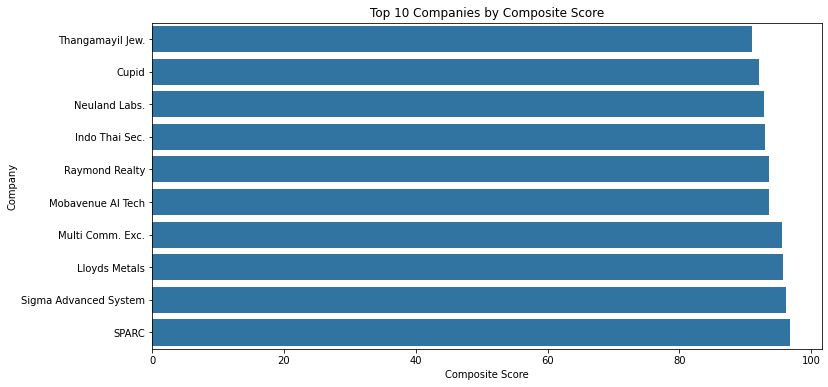

In [45]:
top_10 = ranking.head(10).sort_values(
    "Composite_Score",
    ascending=True
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_10,
    x="Composite_Score",
    y="Company"
)

plt.title("Top 10 Companies by Composite Score")
plt.xlabel("Composite Score")
plt.ylabel("Company")

plt.show()

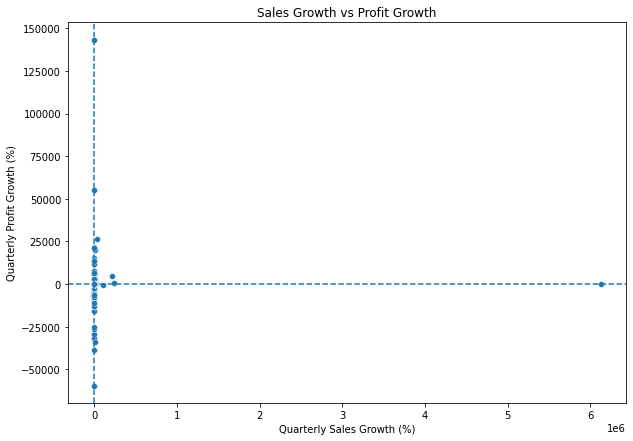

In [46]:
growth_df = df[
    [
        "Company",
        "Quarterly_Sales_Growth_Percent",
        "Quarterly_Profit_Growth_Percent"
    ]
].dropna().copy()

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=growth_df,
    x="Quarterly_Sales_Growth_Percent",
    y="Quarterly_Profit_Growth_Percent"
)

plt.title("Sales Growth vs Profit Growth")
plt.xlabel("Quarterly Sales Growth (%)")
plt.ylabel("Quarterly Profit Growth (%)")

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.show()

Sales Growth range: -74.92 to 216.185
Profit Growth range: -333.4275 to 600.0
Jumlah data: 3992


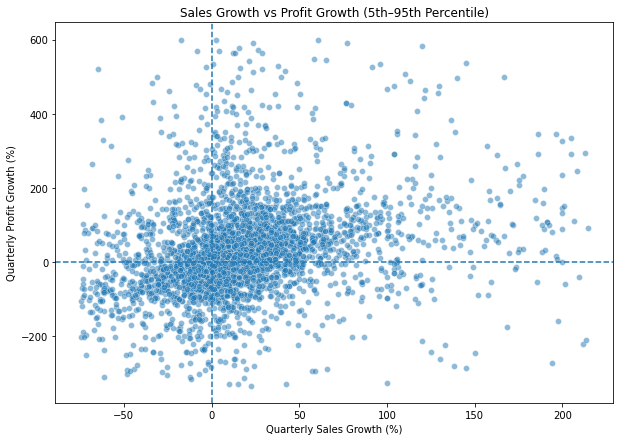

In [47]:
sales_lower = df["Quarterly_Sales_Growth_Percent"].quantile(0.05)
sales_upper = df["Quarterly_Sales_Growth_Percent"].quantile(0.95)

profit_lower = df["Quarterly_Profit_Growth_Percent"].quantile(0.05)
profit_upper = df["Quarterly_Profit_Growth_Percent"].quantile(0.95)

growth_plot = df[
    (df["Quarterly_Sales_Growth_Percent"] >= sales_lower) &
    (df["Quarterly_Sales_Growth_Percent"] <= sales_upper) &
    (df["Quarterly_Profit_Growth_Percent"] >= profit_lower) &
    (df["Quarterly_Profit_Growth_Percent"] <= profit_upper)
][
    [
        "Company",
        "Quarterly_Sales_Growth_Percent",
        "Quarterly_Profit_Growth_Percent"
    ]
].dropna()

print("Sales Growth range:", sales_lower, "to", sales_upper)
print("Profit Growth range:", profit_lower, "to", profit_upper)
print("Jumlah data:", len(growth_plot))

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=growth_plot,
    x="Quarterly_Sales_Growth_Percent",
    y="Quarterly_Profit_Growth_Percent",
    alpha=0.5
)

plt.title("Sales Growth vs Profit Growth (5th–95th Percentile)")
plt.xlabel("Quarterly Sales Growth (%)")
plt.ylabel("Quarterly Profit Growth (%)")

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.show()

Dari grafik Sales Growth vs Profit Growth (5th–95th Percentile):

1. Sebagian besar perusahaan terkonsentrasi di sekitar Sales Growth 0–50% dan Profit Growth -100% sampai 100%.
2. Titik di kuadran kanan atas (Sales ↑, Profit ↑) cukup banyak. Ini menunjukkan banyak perusahaan mengalami pertumbuhan penjualan sekaligus pertumbuhan profit.
3. Kuadran kanan bawah (Sales ↑, Profit ↓) juga cukup terlihat. Artinya ada perusahaan yang berhasil meningkatkan penjualan tetapi profitnya justru menurun.
4. Kuadran kiri bawah (Sales ↓, Profit ↓) juga cukup padat, menunjukkan sebagian perusahaan mengalami kontraksi baik pada sales maupun profit.
5. Kuadran kiri atas (Sales ↓, Profit ↑) relatif lebih sedikit.

Pertumbuhan sales tidak selalu diikuti oleh pertumbuhan profit. Meskipun 47,01% perusahaan mengalami peningkatan sales dan profit secara bersamaan, sekitar 21,88% mengalami peningkatan sales tetapi penurunan profit.